# Import Environment variables

In [85]:
%run /home/jupyter/repos/Multi-trait-GWAS-in-admixed-populations/notebooks/Setting_Env_Variables.ipynb

Found bucket: id=rw-migration-aou-rw-f7a4d148, bucketName=rw-migration-aou-rw-f7a4d148
-> Assigned migration variables (ID: rw-migration-aou-rw-f7a4d148)
Found bucket: id=temporary-workspace-bucket, bucketName=temporary-workspace-bucket-wb-perky-cabbage-8342
Found bucket: id=workspace-bucket, bucketName=workspace-bucket-wb-perky-cabbage-8342
✅ Successfully identified latest dataset: wb-silky-artichoke-2408.C2024Q3R9

Variables extracted:
GOOGLE_CLOUD_PROJECT: wb-perky-cabbage-8342
WORKSPACE_BUCKET: gs://workspace-bucket-wb-perky-cabbage-8342
WORKSPACE_TEMP_BUCKET: gs://temporary-workspace-bucket-wb-perky-cabbage-8342
WORKSPACE_CDR: wb-silky-artichoke-2408.C2024Q3R9
bucket_aou_tutorial: NOT FOUND
bucket_id_aou_tutorial: NOT FOUND
bucket_migrated: gs://rw-migration-aou-rw-f7a4d148
bucket_id_migrated: rw-migration-aou-rw-f7a4d148

✅ Saved to /home/jupyter/.bashrc
C2024Q3R9 BQ_DATASET
Multi-trait-GWAS-in-admixed-populations GIT_REPO
dataset_test2 BQ_DATASET
prep_C2024Q3R9 BQ_DATASET
rw-mig

In [86]:
%run /home/jupyter/repos/Multi-trait-GWAS-in-admixed-populations/notebooks/Setting_Env_Variables_p2.ipynb

WORKSPACE_CDR = wb-silky-artichoke-2408.C2024Q3R9
WORKSPACE_BUCKET = gs://workspace-bucket-wb-perky-cabbage-8342
GOOGLE_PROJECT = wb-perky-cabbage-8342
Done! 10 variables saved to: /home/jupyter/repos/Multi-trait-GWAS-in-admixed-populations/notebooks/Setting_Env_Variables_p2.R
Done! 10 variables saved to: /home/jupyter/repos/Multi-trait-GWAS-in-admixed-populations/notebooks/Setting_Env_Variables.sas


# Librairy

In [87]:
%load_ext autoreload
%autoreload 2

import os
import subprocess
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from itertools import combinations

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Data's import

## Data from 51_BC_WITHIN_5Y_GeneticAncestry_Treatment

* Femmes n'ayant pas eu de cancer avant l'inclusion (BC and not BC included without time constraints) for all time)
* Origine génétique (RYE)

In [88]:
# get the bucket name
my_bucket = os.getenv('WORKSPACE_TEMP_BUCKET')

name_of_file_in_bucket = "df_bc_ko_at_inclusion_223k_nb_BC_WITHIN_5Y_GeneticAncestry.tsv"

# save dataframe in a csv file in the same workspace as the notebook
df_bc = pd.read_csv(my_bucket +'/'+ name_of_file_in_bucket)
df_bc

,person_id,gender,date_of_birth,ethnicity,self_reported_category,inclusion_date,first_breast_cancer_date,delay_days,delay_years,time_category,age_at_inclusion,has_bc,eur_rye,eas_rye,amr_rye,afr_rye,sas_rye,mid_rye,dominant_origin,ancestry_80
0,7604109,Female,1953-06-15,Not Hispanic or Latino,Native Hawaiian or Other Pacific Islander,2022-03-29,NaN,NaN,NaN,NaN,68.785763,0,0.235991,0.600594,0.001856,0.013219,0.068500,0.079841,eas_rye,eur / eas
1,2382559,Female,1988-06-15,Not Hispanic or Latino,Native Hawaiian or Other Pacific Islander,2022-04-04,NaN,NaN,NaN,NaN,33.801506,0,0.000000,0.800049,0.000000,0.021460,0.178492,0.000000,eas_rye,eas_rye
2,2032331,Female,1954-06-15,Not Hispanic or Latino,Native Hawaiian or Other Pacific Islander,2019-09-17,NaN,NaN,NaN,NaN,65.256674,0,0.874544,0.000000,0.034004,0.000000,0.022198,0.069255,eur_rye,eur_rye
3,3382692,Female,1957-06-15,Not Hispanic or Latino,Native Hawaiian or Other Pacific Islander,2018-07-17,NaN,NaN,NaN,NaN,61.086927,0,0.045438,0.772877,0.065447,0.000000,0.055573,0.060666,eas_rye,eur / eas
4,2537673,Female,1965-06-15,Not Hispanic or Latino,Native Hawaiian or Other Pacific Islander,2019-03-04,NaN,NaN,NaN,NaN,53.716632,0,0.790872,0.004602,0.156245,0.000834,0.026033,0.021413,eur_rye,eur / amr
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
223201,8122695,Female,2002-06-15,Not Hispanic or Latino,White,2023-06-21,NaN,NaN,NaN,NaN,21.015743,0,0.889956,0.000000,0.038217,0.000000,0.047237,0.024590,eur_rye,eur_rye
223202,3902303,Female,2003-06-15,Not Hispanic or Latino,White,2022-12-12,NaN,NaN,NaN,NaN,19.493498,0,0.864528,0.000000,0.022656,0.000000,0.046108,0.066707,eur_rye,eur_rye
223203,9743793,Female,2003-06-15,Not Hispanic or Latino,White,2022-12-27,NaN,NaN,NaN,NaN,19.534565,0,0.884746,0.000000,0.037232,0.000000,0.078022,0.000000,eur_rye,eur_rye
223204,4702863,Female,2003-06-15,Not Hispanic or Latino,White,2023-02-24,NaN,NaN,NaN,NaN,19.696099,0,0.350078,0.000000,0.072839,0.000000,0.040098,0.536984,mid_rye,eur / mid


# Biopsy data processing

Le principe de prendre la biopsie comme marqueur de risque, c’est la biopsie au sens diagnostique

## Biopsy 19081-19086

**19081 -> 19086 :** Biopsy, breast, with placement of breast localization device(s) (eg, clip, metallic pellet), when performed, and imaging of the biopsy specimen, when performed, percutaneous; :
* **19081 ->** [..] first lesion, **including stereotactic guidance**
* **19082 ->** [..] each additional lesion, **stereotactic guidance** (List separately additi...)
* **19083 ->** [..] first lesions, **including ultrasound guidance**
* **19084 ->**  [..] each additional lesion, **including ultrasound guidance** (List separately additi...)
* **19085 ->** [..] first lesions, **including magnetic resonance guidance**
* **19086 ->**  [..] each additional lesion, **including magnetic resonance guidance** (List separately additi...)

### Importing Biopsy data

In [89]:
# This query represents dataset "biopsy 19081-19086" for domain "procedure" and was generated for All of Us Controlled Tier Dataset v8
dataset_82834044_procedure_sql = """
    SELECT
        procedure.person_id,
        procedure.procedure_concept_id,
        p_standard_concept.concept_name as standard_concept_name,
        p_standard_concept.concept_code as standard_concept_code,
        p_standard_concept.vocabulary_id as standard_vocabulary,
        procedure.procedure_datetime,
        procedure.procedure_type_concept_id,
        p_type.concept_name as procedure_type_concept_name,
        procedure.modifier_concept_id,
        p_modifier.concept_name as modifier_concept_name,
        procedure.quantity,
        procedure.visit_occurrence_id,
        p_visit.concept_name as visit_occurrence_concept_name,
        procedure.procedure_source_value,
        procedure.procedure_source_concept_id,
        p_source_concept.concept_name as source_concept_name,
        p_source_concept.concept_code as source_concept_code,
        p_source_concept.vocabulary_id as source_vocabulary,
        procedure.modifier_source_value 
    FROM
        ( SELECT
            * 
        FROM
            `""" + os.environ["WORKSPACE_CDR"] + """.procedure_occurrence` procedure 
        WHERE
            (
                procedure_source_concept_id IN (SELECT
                    DISTINCT c.concept_id 
                FROM
                    `""" + os.environ["WORKSPACE_CDR"] + """.cb_criteria` c 
                JOIN
                    (SELECT
                        CAST(cr.id as string) AS id       
                    FROM
                        `""" + os.environ["WORKSPACE_CDR"] + """.cb_criteria` cr       
                    WHERE
                        concept_id IN (44816374, 44816375, 44816376, 44816377, 44816378, 44816379)       
                        AND full_text LIKE '%_rank1]%'      ) a 
                        ON (c.path LIKE CONCAT('%.', a.id, '.%') 
                        OR c.path LIKE CONCAT('%.', a.id) 
                        OR c.path LIKE CONCAT(a.id, '.%') 
                        OR c.path = a.id) 
                WHERE
                    is_standard = 0 
                    AND is_selectable = 1)
            )) procedure 
    LEFT JOIN
        `""" + os.environ["WORKSPACE_CDR"] + """.concept` p_standard_concept 
            ON procedure.procedure_concept_id = p_standard_concept.concept_id 
    LEFT JOIN
        `""" + os.environ["WORKSPACE_CDR"] + """.concept` p_type 
            ON procedure.procedure_type_concept_id = p_type.concept_id 
    LEFT JOIN
        `""" + os.environ["WORKSPACE_CDR"] + """.concept` p_modifier 
            ON procedure.modifier_concept_id = p_modifier.concept_id 
    LEFT JOIN
        `""" + os.environ["WORKSPACE_CDR"] + """.visit_occurrence` v 
            ON procedure.visit_occurrence_id = v.visit_occurrence_id 
    LEFT JOIN
        `""" + os.environ["WORKSPACE_CDR"] + """.concept` p_visit 
            ON v.visit_concept_id = p_visit.concept_id 
    LEFT JOIN
        `""" + os.environ["WORKSPACE_CDR"] + """.concept` p_source_concept 
            ON procedure.procedure_source_concept_id = p_source_concept.concept_id"""

dataset_82834044_procedure_df = pd.read_gbq(
    dataset_82834044_procedure_sql,
    dialect="standard",
    use_bqstorage_api=("BIGQUERY_STORAGE_API_ENABLED" in os.environ),
    progress_bar_type="tqdm_notebook")

dataset_82834044_procedure_df

Downloading:   0%|          |

,person_id,procedure_concept_id,standard_concept_name,standard_concept_code,standard_vocabulary,procedure_datetime,procedure_type_concept_id,procedure_type_concept_name,modifier_concept_id,modifier_concept_name,quantity,visit_occurrence_id,visit_occurrence_concept_name,procedure_source_value,procedure_source_concept_id,source_concept_name,source_concept_code,source_vocabulary,modifier_source_value
0,2997501,44816375,"Biopsy, breast, with placement of breast local...",19082,CPT4,2021-07-14 18:05:00+00:00,38000275,EHR order list entry,0,No matching concept,1,<NA>,None,19082,44816375,"Biopsy, breast, with placement of breast local...",19082,CPT4,No matching concept
1,9721208,44816375,"Biopsy, breast, with placement of breast local...",19082,CPT4,2020-10-12 07:00:00+00:00,0,No matching concept,0,No matching concept,0,<NA>,None,19082,44816375,"Biopsy, breast, with placement of breast local...",19082,CPT4,No matching concept
2,2230755,44816375,"Biopsy, breast, with placement of breast local...",19082,CPT4,2015-08-14 07:00:00+00:00,0,No matching concept,0,No matching concept,0,<NA>,None,19082,44816375,"Biopsy, breast, with placement of breast local...",19082,CPT4,No matching concept
3,2619746,44816375,"Biopsy, breast, with placement of breast local...",19082,CPT4,2020-11-19 00:00:00+00:00,32817,EHR,<NA>,None,1,65000000000358271,None,19082,44816375,"Biopsy, breast, with placement of breast local...",19082,CPT4,None
4,1696747,44816375,"Biopsy, breast, with placement of breast local...",19082,CPT4,2022-07-21 18:16:00+00:00,38000275,EHR order list entry,0,No matching concept,1,<NA>,None,19082,44816375,"Biopsy, breast, with placement of breast local...",19082,CPT4,No matching concept
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18349,1273522,44816374,"Biopsy, breast, with placement of breast local...",19081,CPT4,2019-11-26 00:00:00+00:00,32833,EHR order,42628420,This service has been performed in part by a r...,1,<NA>,None,19081,44816374,"Biopsy, breast, with placement of breast local...",19081,CPT4,GC
18350,1149508,44816374,"Biopsy, breast, with placement of breast local...",19081,CPT4,2020-06-30 07:55:00+00:00,32833,EHR order,0,No matching concept,1,<NA>,None,19081,44816374,"Biopsy, breast, with placement of breast local...",19081,CPT4,No matching concept
18351,6375171,44816374,"Biopsy, breast, with placement of breast local...",19081,CPT4,2023-07-17 18:58:00+00:00,38000275,EHR order list entry,0,No matching concept,1,<NA>,None,19081,44816374,"Biopsy, breast, with placement of breast local...",19081,CPT4,No matching concept
18352,2299043,44816374,"Biopsy, breast, with placement of breast local...",19081,CPT4,2020-01-13 09:42:00+00:00,32833,EHR order,0,No matching concept,1,<NA>,None,19081,44816374,"Biopsy, breast, with placement of breast local...",19081,CPT4,No matching concept


### Have individuals reported multiple biopsy diagnoses ?

In [90]:
# Nombre de déclaration par individu
dataset_82834044_procedure_df[['person_id']].value_counts()

person_id
2117870      27
2039414      24
1035618      24
1267280      24
2024344      24
             ..
9971321       1
9974627       1
9934245       1
9939292       1
9942190       1
Name: count, Length: 8719, dtype: int64

In [91]:
# Observation des biopsies unique pour un individu qui en a déclaré plusieurs
dataset_82834044_procedure_df[dataset_82834044_procedure_df['person_id'] == 2117870].drop_duplicates()[['person_id','procedure_datetime','visit_occurrence_id']]

,person_id,procedure_datetime,visit_occurrence_id
2350,2117870,2018-12-06 00:00:00+00:00,31000000000179902
3710,2117870,2018-12-06 00:00:00+00:00,31000000000179901
4323,2117870,2021-05-18 00:00:00+00:00,31000000000176454
6155,2117870,2018-12-06 00:00:00+00:00,31000000000179900
6961,2117870,2018-12-06 00:00:00+00:00,31000000000179899
11708,2117870,2018-12-06 00:00:00+00:00,31000000000179902
11863,2117870,2018-12-06 00:00:00+00:00,31000000000179901
12152,2117870,2018-12-06 00:00:00+00:00,31000000000179900
12247,2117870,2018-12-06 00:00:00+00:00,31000000000179899


### Management of biopsy dates (adding a column for each date)

#### Define a function

In [92]:
def process_procedure_dates(procedure_df, date_col='procedure_datetime', n_dates=3, prefix='biopsy', main_set=df_bc):
    """
    Transforme un DataFrame de procédures (format long) en un résumé par individu (format wide)
    en ne gardant que les N premières dates uniques.
    """
    # 1. Copie pour éviter de modifier l'original et conversion datetime
    df_temp = procedure_df.copy()
    df_temp[date_col] = pd.to_datetime(df_temp[date_col])
    
    # 2. Récupération des dates uniques triées par patient
    # On utilise .dt.date pour ignorer l'heure si elle n'est pas nécessaire
    unique_dates = df_temp.groupby('person_id')[date_col] \
                    .apply(lambda x: sorted(x.unique())) \
                    .reset_index()
    
    # 3. Création des colonnes séparées
    # On transforme la liste de dates en colonnes
    dates_expanded = pd.DataFrame(unique_dates[date_col].tolist(), index=unique_dates.index)
    
    # On ne garde que les N premières colonnes disponibles
    dates_expanded = dates_expanded.iloc[:, :n_dates]
    
    # Renommage dynamique des colonnes
    new_col_names = [f'date_{i+1}_of_{prefix}' for i in range(dates_expanded.shape[1])]
    dates_expanded.columns = new_col_names
    
    # 4. Reconstruction finale avec person_id
    result = pd.concat([unique_dates['person_id'], dates_expanded], axis=1)
    
    # 5. Ajout d'une colonne binaire simple pour faciliter les filtres rapides
    result[f'has_{prefix}'] = 1
    
    # 6. Fusion avec votre DataFrame principal (df)
    final_result = pd.merge(main_set, result, on='person_id', how='left')
    
    # 7. Remplissage des 0 pour ceux qui n'ont pas eu de biopsie
    final_result[f'has_{prefix}'] = final_result[f'has_{prefix}'].fillna(0).astype(int)
    
    return final_result

#### Application of the function

In [93]:
df_biopsy_19081_19086 = process_procedure_dates(
    dataset_82834044_procedure_df,
    n_dates=3,
    prefix='biopsy_19081_19086',
    main_set=df_bc)

df_biopsy_19081_19086

,person_id,gender,date_of_birth,ethnicity,self_reported_category,inclusion_date,first_breast_cancer_date,delay_days,delay_years,time_category,...,amr_rye,afr_rye,sas_rye,mid_rye,dominant_origin,ancestry_80,date_1_of_biopsy_19081_19086,date_2_of_biopsy_19081_19086,date_3_of_biopsy_19081_19086,has_biopsy_19081_19086
0,7604109,Female,1953-06-15,Not Hispanic or Latino,Native Hawaiian or Other Pacific Islander,2022-03-29,NaN,NaN,NaN,NaN,...,0.001856,0.013219,0.068500,0.079841,eas_rye,eur / eas,NaT,NaT,NaT,0
1,2382559,Female,1988-06-15,Not Hispanic or Latino,Native Hawaiian or Other Pacific Islander,2022-04-04,NaN,NaN,NaN,NaN,...,0.000000,0.021460,0.178492,0.000000,eas_rye,eas_rye,NaT,NaT,NaT,0
2,2032331,Female,1954-06-15,Not Hispanic or Latino,Native Hawaiian or Other Pacific Islander,2019-09-17,NaN,NaN,NaN,NaN,...,0.034004,0.000000,0.022198,0.069255,eur_rye,eur_rye,NaT,NaT,NaT,0
3,3382692,Female,1957-06-15,Not Hispanic or Latino,Native Hawaiian or Other Pacific Islander,2018-07-17,NaN,NaN,NaN,NaN,...,0.065447,0.000000,0.055573,0.060666,eas_rye,eur / eas,NaT,NaT,NaT,0
4,2537673,Female,1965-06-15,Not Hispanic or Latino,Native Hawaiian or Other Pacific Islander,2019-03-04,NaN,NaN,NaN,NaN,...,0.156245,0.000834,0.026033,0.021413,eur_rye,eur / amr,NaT,NaT,NaT,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
223201,8122695,Female,2002-06-15,Not Hispanic or Latino,White,2023-06-21,NaN,NaN,NaN,NaN,...,0.038217,0.000000,0.047237,0.024590,eur_rye,eur_rye,NaT,NaT,NaT,0
223202,3902303,Female,2003-06-15,Not Hispanic or Latino,White,2022-12-12,NaN,NaN,NaN,NaN,...,0.022656,0.000000,0.046108,0.066707,eur_rye,eur_rye,NaT,NaT,NaT,0
223203,9743793,Female,2003-06-15,Not Hispanic or Latino,White,2022-12-27,NaN,NaN,NaN,NaN,...,0.037232,0.000000,0.078022,0.000000,eur_rye,eur_rye,NaT,NaT,NaT,0
223204,4702863,Female,2003-06-15,Not Hispanic or Latino,White,2023-02-24,NaN,NaN,NaN,NaN,...,0.072839,0.000000,0.040098,0.536984,mid_rye,eur / mid,NaT,NaT,NaT,0


In [94]:
df_biopsy_19081_19086['has_biopsy_19081_19086'].value_counts()

has_biopsy_19081_19086
0    219132
1      4074
Name: count, dtype: int64

### Percentage of individuals who underwent a biopsy (19081-19086)

In [95]:
total_biopsy = df_biopsy_19081_19086[df_biopsy_19081_19086['has_biopsy_19081_19086'] == 1].value_counts('has_bc')[1]

(total_biopsy/df_biopsy_19081_19086.shape[0])*100

np.float64(0.2311765812746969)

## Biopsy 19100-19103

**19100 -> 19103 :**
* **19100 ->** Biopsy of breast; percutaneous, needle core, not using imaging guidance (separate procedure)
* **19101 ->** Biopsy of breast; open, incisional
* **19102 ->** Biopsy of breast; percutaneous, needle core, using imaging guidance
* **19103 ->** Biopsy of breast; percutaneous, automated vacuum assisted or rotating biopsy device, using imaging guidance

### Importing Biopsy data

In [96]:
import pandas
import os

# This query represents dataset "Biopsy (19100-19103" for domain "procedure" and was generated for All of Us Controlled Tier Dataset v8
dataset_03190855_procedure_sql = """
    SELECT
        procedure.person_id,
        procedure.procedure_concept_id,
        p_standard_concept.concept_name as standard_concept_name,
        p_standard_concept.concept_code as standard_concept_code,
        p_standard_concept.vocabulary_id as standard_vocabulary,
        procedure.procedure_datetime,
        procedure.procedure_type_concept_id,
        p_type.concept_name as procedure_type_concept_name,
        procedure.modifier_concept_id,
        p_modifier.concept_name as modifier_concept_name,
        procedure.quantity,
        procedure.visit_occurrence_id,
        p_visit.concept_name as visit_occurrence_concept_name,
        procedure.procedure_source_value,
        procedure.procedure_source_concept_id,
        p_source_concept.concept_name as source_concept_name,
        p_source_concept.concept_code as source_concept_code,
        p_source_concept.vocabulary_id as source_vocabulary,
        procedure.modifier_source_value 
    FROM
        ( SELECT
            * 
        FROM
            `""" + os.environ["WORKSPACE_CDR"] + """.procedure_occurrence` procedure 
        WHERE
            (
                procedure_source_concept_id IN (SELECT
                    DISTINCT c.concept_id 
                FROM
                    `""" + os.environ["WORKSPACE_CDR"] + """.cb_criteria` c 
                JOIN
                    (SELECT
                        CAST(cr.id as string) AS id       
                    FROM
                        `""" + os.environ["WORKSPACE_CDR"] + """.cb_criteria` cr       
                    WHERE
                        concept_id IN (2102672, 2102673, 2102674, 2102675)       
                        AND full_text LIKE '%_rank1]%'      ) a 
                        ON (c.path LIKE CONCAT('%.', a.id, '.%') 
                        OR c.path LIKE CONCAT('%.', a.id) 
                        OR c.path LIKE CONCAT(a.id, '.%') 
                        OR c.path = a.id) 
                WHERE
                    is_standard = 0 
                    AND is_selectable = 1)
            )) procedure 
    LEFT JOIN
        `""" + os.environ["WORKSPACE_CDR"] + """.concept` p_standard_concept 
            ON procedure.procedure_concept_id = p_standard_concept.concept_id 
    LEFT JOIN
        `""" + os.environ["WORKSPACE_CDR"] + """.concept` p_type 
            ON procedure.procedure_type_concept_id = p_type.concept_id 
    LEFT JOIN
        `""" + os.environ["WORKSPACE_CDR"] + """.concept` p_modifier 
            ON procedure.modifier_concept_id = p_modifier.concept_id 
    LEFT JOIN
        `""" + os.environ["WORKSPACE_CDR"] + """.visit_occurrence` v 
            ON procedure.visit_occurrence_id = v.visit_occurrence_id 
    LEFT JOIN
        `""" + os.environ["WORKSPACE_CDR"] + """.concept` p_visit 
            ON v.visit_concept_id = p_visit.concept_id 
    LEFT JOIN
        `""" + os.environ["WORKSPACE_CDR"] + """.concept` p_source_concept 
            ON procedure.procedure_source_concept_id = p_source_concept.concept_id"""

dataset_03190855_procedure_df = pd.read_gbq(
    dataset_03190855_procedure_sql,
    dialect="standard",
    use_bqstorage_api=("BIGQUERY_STORAGE_API_ENABLED" in os.environ),
    progress_bar_type="tqdm_notebook")

dataset_03190855_procedure_df

Downloading:   0%|          |

,person_id,procedure_concept_id,standard_concept_name,standard_concept_code,standard_vocabulary,procedure_datetime,procedure_type_concept_id,procedure_type_concept_name,modifier_concept_id,modifier_concept_name,quantity,visit_occurrence_id,visit_occurrence_concept_name,procedure_source_value,procedure_source_concept_id,source_concept_name,source_concept_code,source_vocabulary,modifier_source_value
0,1576415,2102674,"Biopsy of breast; percutaneous, needle core, u...",19102,CPT4,2007-04-04 12:59:00+00:00,32817,EHR,0,No matching concept,1,69000000002150801,None,19102,2102674,"Biopsy of breast; percutaneous, needle core, u...",19102,CPT4,No matching concept
1,1418414,2102674,"Biopsy of breast; percutaneous, needle core, u...",19102,CPT4,2004-05-20 00:00:00+00:00,32833,EHR order,<NA>,None,1,<NA>,None,19102,2102674,"Biopsy of breast; percutaneous, needle core, u...",19102,CPT4,None
2,5174481,2102674,"Biopsy of breast; percutaneous, needle core, u...",19102,CPT4,2011-02-25 11:13:00+00:00,32817,EHR,0,No matching concept,1,69000000002164298,None,19102,2102674,"Biopsy of breast; percutaneous, needle core, u...",19102,CPT4,No matching concept
3,1576415,2102674,"Biopsy of breast; percutaneous, needle core, u...",19102,CPT4,2007-04-04 12:59:00+00:00,32833,EHR order,0,No matching concept,1,69000000002150801,None,19102,2102674,"Biopsy of breast; percutaneous, needle core, u...",19102,CPT4,No matching concept
4,1761480,2102674,"Biopsy of breast; percutaneous, needle core, u...",19102,CPT4,2013-12-19 00:00:00+00:00,32833,EHR order,42739588,Distinct Procedural Service,1,<NA>,None,19102,2102674,"Biopsy of breast; percutaneous, needle core, u...",19102,CPT4,59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4300,1556292,2102675,"Biopsy of breast; percutaneous, automated vacu...",19103,CPT4,2013-02-28 00:00:00+00:00,0,No matching concept,0,No matching concept,<NA>,37000000012786682,Outpatient Visit,19103,2102675,"Biopsy of breast; percutaneous, automated vacu...",19103,CPT4,No matching concept
4301,6112026,2102675,"Biopsy of breast; percutaneous, automated vacu...",19103,CPT4,2013-08-26 00:00:00+00:00,38000275,EHR order list entry,0,No matching concept,0,31000000000048317,Outpatient Visit,19103,2102675,"Biopsy of breast; percutaneous, automated vacu...",19103,CPT4,No matching concept
4302,6112026,2102675,"Biopsy of breast; percutaneous, automated vacu...",19103,CPT4,2013-08-26 00:00:00+00:00,38000275,EHR order list entry,0,No matching concept,0,31000000000048317,Outpatient Visit,19103,2102675,"Biopsy of breast; percutaneous, automated vacu...",19103,CPT4,No matching concept
4303,2609521,2102675,"Biopsy of breast; percutaneous, automated vacu...",19103,CPT4,2011-10-31 00:00:00+00:00,44786630,Primary Procedure,<NA>,None,1,42000000027134033,Outpatient Visit,19103,2102675,"Biopsy of breast; percutaneous, automated vacu...",19103,CPT4,None


### Have individuals reported multiple biopsy diagnoses ?

In [97]:
dataset_03190855_procedure_df['standard_concept_code'].value_counts()

standard_concept_code
19103        2108
19102        1676
44578009      324
237378001     197
Name: count, dtype: int64

In [98]:
# Observation des biopsies unique pour un individu qui en a déclaré plusieurs
dataset_03190855_procedure_df[dataset_03190855_procedure_df['person_id'] == 2117870].drop_duplicates()[['person_id','procedure_datetime','visit_occurrence_id']]

,person_id,procedure_datetime,visit_occurrence_id


### Management of biopsy dates (adding a column for each date)

In [99]:
df_biopsy_19100_19103 = process_procedure_dates(
    dataset_03190855_procedure_df,
    n_dates=3,
    prefix='biopsy_19100_19103',
    main_set=df_biopsy_19081_19086)

df_biopsy_19100_19103

,person_id,gender,date_of_birth,ethnicity,self_reported_category,inclusion_date,first_breast_cancer_date,delay_days,delay_years,time_category,...,dominant_origin,ancestry_80,date_1_of_biopsy_19081_19086,date_2_of_biopsy_19081_19086,date_3_of_biopsy_19081_19086,has_biopsy_19081_19086,date_1_of_biopsy_19100_19103,date_2_of_biopsy_19100_19103,date_3_of_biopsy_19100_19103,has_biopsy_19100_19103
0,7604109,Female,1953-06-15,Not Hispanic or Latino,Native Hawaiian or Other Pacific Islander,2022-03-29,NaN,NaN,NaN,NaN,...,eas_rye,eur / eas,NaT,NaT,NaT,0,NaT,NaT,NaT,0
1,2382559,Female,1988-06-15,Not Hispanic or Latino,Native Hawaiian or Other Pacific Islander,2022-04-04,NaN,NaN,NaN,NaN,...,eas_rye,eas_rye,NaT,NaT,NaT,0,NaT,NaT,NaT,0
2,2032331,Female,1954-06-15,Not Hispanic or Latino,Native Hawaiian or Other Pacific Islander,2019-09-17,NaN,NaN,NaN,NaN,...,eur_rye,eur_rye,NaT,NaT,NaT,0,NaT,NaT,NaT,0
3,3382692,Female,1957-06-15,Not Hispanic or Latino,Native Hawaiian or Other Pacific Islander,2018-07-17,NaN,NaN,NaN,NaN,...,eas_rye,eur / eas,NaT,NaT,NaT,0,NaT,NaT,NaT,0
4,2537673,Female,1965-06-15,Not Hispanic or Latino,Native Hawaiian or Other Pacific Islander,2019-03-04,NaN,NaN,NaN,NaN,...,eur_rye,eur / amr,NaT,NaT,NaT,0,NaT,NaT,NaT,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
223201,8122695,Female,2002-06-15,Not Hispanic or Latino,White,2023-06-21,NaN,NaN,NaN,NaN,...,eur_rye,eur_rye,NaT,NaT,NaT,0,NaT,NaT,NaT,0
223202,3902303,Female,2003-06-15,Not Hispanic or Latino,White,2022-12-12,NaN,NaN,NaN,NaN,...,eur_rye,eur_rye,NaT,NaT,NaT,0,NaT,NaT,NaT,0
223203,9743793,Female,2003-06-15,Not Hispanic or Latino,White,2022-12-27,NaN,NaN,NaN,NaN,...,eur_rye,eur_rye,NaT,NaT,NaT,0,NaT,NaT,NaT,0
223204,4702863,Female,2003-06-15,Not Hispanic or Latino,White,2023-02-24,NaN,NaN,NaN,NaN,...,mid_rye,eur / mid,NaT,NaT,NaT,0,NaT,NaT,NaT,0


In [100]:
df_biopsy_19100_19103['has_biopsy_19100_19103'].value_counts()

has_biopsy_19100_19103
0    222193
1      1013
Name: count, dtype: int64

### Percentage of individuals who underwent a biopsy (19100-19103)

In [101]:
total_biopsy = df_biopsy_19100_19103[df_biopsy_19100_19103['has_biopsy_19100_19103'] == 1].value_counts('has_bc')[1]

(total_biopsy/df_biopsy_19100_19103.shape[0])*100

np.float64(0.01209644902018763)

## Biopsy 19120 + 19125-19126

**19120 + 19125 - 19126 :**
* **19120 ->** Excision of cyst, fibroadenoma, or other benign or malignant tumor, aberrant breast tissue, duct lesion, nipple or areolar lesion (except 19300), open, male or female, 1 or more lesions
* **19125 ->** Excision of breast lesion identified by preoperative placement of radiological marker, open; single lesion
* **19126 ->** Excision of breast lesion identified by preoperative placement of radiological marker, open; each additional lesion separately identified by a preoperative radiological marker (List separately in addition to code for primary procedure)

### Importing Biopsy data

In [102]:
import pandas
import os

# This query represents dataset "Biopsy 19120 + 19125-19126" for domain "procedure" and was generated for All of Us Controlled Tier Dataset v8
dataset_92591342_procedure_sql = """
    SELECT
        procedure.person_id,
        procedure.procedure_concept_id,
        p_standard_concept.concept_name as standard_concept_name,
        p_standard_concept.concept_code as standard_concept_code,
        p_standard_concept.vocabulary_id as standard_vocabulary,
        procedure.procedure_datetime,
        procedure.procedure_type_concept_id,
        p_type.concept_name as procedure_type_concept_name,
        procedure.modifier_concept_id,
        p_modifier.concept_name as modifier_concept_name,
        procedure.quantity,
        procedure.visit_occurrence_id,
        p_visit.concept_name as visit_occurrence_concept_name,
        procedure.procedure_source_value,
        procedure.procedure_source_concept_id,
        p_source_concept.concept_name as source_concept_name,
        p_source_concept.concept_code as source_concept_code,
        p_source_concept.vocabulary_id as source_vocabulary,
        procedure.modifier_source_value 
    FROM
        ( SELECT
            * 
        FROM
            `""" + os.environ["WORKSPACE_CDR"] + """.procedure_occurrence` procedure 
        WHERE
            (
                procedure_source_concept_id IN (SELECT
                    DISTINCT c.concept_id 
                FROM
                    `""" + os.environ["WORKSPACE_CDR"] + """.cb_criteria` c 
                JOIN
                    (SELECT
                        CAST(cr.id as string) AS id       
                    FROM
                        `""" + os.environ["WORKSPACE_CDR"] + """.cb_criteria` cr       
                    WHERE
                        concept_id IN (2102679, 2102680, 2102681)       
                        AND full_text LIKE '%_rank1]%'      ) a 
                        ON (c.path LIKE CONCAT('%.', a.id, '.%') 
                        OR c.path LIKE CONCAT('%.', a.id) 
                        OR c.path LIKE CONCAT(a.id, '.%') 
                        OR c.path = a.id) 
                WHERE
                    is_standard = 0 
                    AND is_selectable = 1)
            )) procedure 
    LEFT JOIN
        `""" + os.environ["WORKSPACE_CDR"] + """.concept` p_standard_concept 
            ON procedure.procedure_concept_id = p_standard_concept.concept_id 
    LEFT JOIN
        `""" + os.environ["WORKSPACE_CDR"] + """.concept` p_type 
            ON procedure.procedure_type_concept_id = p_type.concept_id 
    LEFT JOIN
        `""" + os.environ["WORKSPACE_CDR"] + """.concept` p_modifier 
            ON procedure.modifier_concept_id = p_modifier.concept_id 
    LEFT JOIN
        `""" + os.environ["WORKSPACE_CDR"] + """.visit_occurrence` v 
            ON procedure.visit_occurrence_id = v.visit_occurrence_id 
    LEFT JOIN
        `""" + os.environ["WORKSPACE_CDR"] + """.concept` p_visit 
            ON v.visit_concept_id = p_visit.concept_id 
    LEFT JOIN
        `""" + os.environ["WORKSPACE_CDR"] + """.concept` p_source_concept 
            ON procedure.procedure_source_concept_id = p_source_concept.concept_id"""

dataset_92591342_procedure_df = pd.read_gbq(
    dataset_92591342_procedure_sql,
    dialect="standard",
    use_bqstorage_api=("BIGQUERY_STORAGE_API_ENABLED" in os.environ),
    progress_bar_type="tqdm_notebook")

dataset_92591342_procedure_df.head(5)

Downloading:   0%|          |

,person_id,procedure_concept_id,standard_concept_name,standard_concept_code,standard_vocabulary,procedure_datetime,procedure_type_concept_id,procedure_type_concept_name,modifier_concept_id,modifier_concept_name,quantity,visit_occurrence_id,visit_occurrence_concept_name,procedure_source_value,procedure_source_concept_id,source_concept_name,source_concept_code,source_vocabulary,modifier_source_value
0,1109767,2102679,"Excision of cyst, fibroadenoma, or other benig...",19120,CPT4,1990-01-01 00:00:00+00:00,0,No matching concept,<NA>,None,<NA>,<NA>,None,19120,2102679,"Excision of cyst, fibroadenoma, or other benig...",19120,CPT4,None
1,1055293,2102679,"Excision of cyst, fibroadenoma, or other benig...",19120,CPT4,2014-11-10 00:00:00+00:00,32810,Claim,42628420,This service has been performed in part by a r...,1,18000000066856586,None,19120,2102679,"Excision of cyst, fibroadenoma, or other benig...",19120,CPT4,GC
2,7007622,2102679,"Excision of cyst, fibroadenoma, or other benig...",19120,CPT4,2017-07-20 07:00:00+00:00,0,No matching concept,0,No matching concept,0,<NA>,None,19120,2102679,"Excision of cyst, fibroadenoma, or other benig...",19120,CPT4,No matching concept
3,7994245,2102679,"Excision of cyst, fibroadenoma, or other benig...",19120,CPT4,2015-04-21 07:00:00+00:00,0,No matching concept,0,No matching concept,0,<NA>,None,19120,2102679,"Excision of cyst, fibroadenoma, or other benig...",19120,CPT4,No matching concept
4,1180744,2102679,"Excision of cyst, fibroadenoma, or other benig...",19120,CPT4,2021-05-03 07:00:00+00:00,0,No matching concept,0,No matching concept,0,<NA>,None,19120,2102679,"Excision of cyst, fibroadenoma, or other benig...",19120,CPT4,No matching concept


### Have individuals reported multiple biopsy diagnoses ?

In [103]:
dataset_92591342_procedure_df['standard_concept_code'].value_counts()

standard_concept_code
19125    2362
19120    1696
19126     147
Name: count, dtype: int64

In [104]:
# Observation des biopsies unique pour un individu qui en a déclaré plusieurs
dataset_92591342_procedure_df[dataset_92591342_procedure_df['person_id'] == 2117870].drop_duplicates()[['person_id','procedure_datetime','visit_occurrence_id']]

,person_id,procedure_datetime,visit_occurrence_id


### Management of biopsy dates (adding a column for each date)

In [105]:
df_biopsy_19120_19125_19126 = process_procedure_dates(
    dataset_92591342_procedure_df,
    n_dates=3,
    prefix='biopsy_19120_19125_19126',
    main_set=df_biopsy_19100_19103)

df_biopsy_19120_19125_19126

,person_id,gender,date_of_birth,ethnicity,self_reported_category,inclusion_date,first_breast_cancer_date,delay_days,delay_years,time_category,...,date_3_of_biopsy_19081_19086,has_biopsy_19081_19086,date_1_of_biopsy_19100_19103,date_2_of_biopsy_19100_19103,date_3_of_biopsy_19100_19103,has_biopsy_19100_19103,date_1_of_biopsy_19120_19125_19126,date_2_of_biopsy_19120_19125_19126,date_3_of_biopsy_19120_19125_19126,has_biopsy_19120_19125_19126
0,7604109,Female,1953-06-15,Not Hispanic or Latino,Native Hawaiian or Other Pacific Islander,2022-03-29,NaN,NaN,NaN,NaN,...,NaT,0,NaT,NaT,NaT,0,NaT,NaT,NaT,0
1,2382559,Female,1988-06-15,Not Hispanic or Latino,Native Hawaiian or Other Pacific Islander,2022-04-04,NaN,NaN,NaN,NaN,...,NaT,0,NaT,NaT,NaT,0,NaT,NaT,NaT,0
2,2032331,Female,1954-06-15,Not Hispanic or Latino,Native Hawaiian or Other Pacific Islander,2019-09-17,NaN,NaN,NaN,NaN,...,NaT,0,NaT,NaT,NaT,0,NaT,NaT,NaT,0
3,3382692,Female,1957-06-15,Not Hispanic or Latino,Native Hawaiian or Other Pacific Islander,2018-07-17,NaN,NaN,NaN,NaN,...,NaT,0,NaT,NaT,NaT,0,NaT,NaT,NaT,0
4,2537673,Female,1965-06-15,Not Hispanic or Latino,Native Hawaiian or Other Pacific Islander,2019-03-04,NaN,NaN,NaN,NaN,...,NaT,0,NaT,NaT,NaT,0,NaT,NaT,NaT,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
223201,8122695,Female,2002-06-15,Not Hispanic or Latino,White,2023-06-21,NaN,NaN,NaN,NaN,...,NaT,0,NaT,NaT,NaT,0,NaT,NaT,NaT,0
223202,3902303,Female,2003-06-15,Not Hispanic or Latino,White,2022-12-12,NaN,NaN,NaN,NaN,...,NaT,0,NaT,NaT,NaT,0,NaT,NaT,NaT,0
223203,9743793,Female,2003-06-15,Not Hispanic or Latino,White,2022-12-27,NaN,NaN,NaN,NaN,...,NaT,0,NaT,NaT,NaT,0,NaT,NaT,NaT,0
223204,4702863,Female,2003-06-15,Not Hispanic or Latino,White,2023-02-24,NaN,NaN,NaN,NaN,...,NaT,0,NaT,NaT,NaT,0,NaT,NaT,NaT,0


In [106]:
df_biopsy_19120_19125_19126['has_biopsy_19120_19125_19126'].value_counts()

has_biopsy_19120_19125_19126
0    222032
1      1174
Name: count, dtype: int64

### Percentage of individuals who underwent a biopsy (19120 + 19125-19126)

In [107]:
total_biopsy = df_biopsy_19120_19125_19126[df_biopsy_19120_19125_19126['has_biopsy_19120_19125_19126'] == 1].value_counts('has_bc')[1]

(total_biopsy/df_biopsy_19120_19125_19126.shape[0])*100

np.float64(0.028225047713771136)

# Feature engineering

## Addition of a `biopsy_result` column (fusion des 3 types de biopsie)

In [108]:
df = df_biopsy_19120_19125_19126.copy()

In [109]:
df["biopsy_result"] = df[
    [
        "has_biopsy_19081_19086",
        "has_biopsy_19100_19103",
        "has_biopsy_19120_19125_19126"
    ]
].max(axis=1)

## Addition of columns `date_X_of_biopsy_19081_19086` containing the biopsy dates (maximum of 3 biopsies)

In [110]:
date_columns = [
    'inclusion_date', 'first_breast_cancer_date',
    'date_1_of_biopsy_19081_19086', 'date_2_of_biopsy_19081_19086', 'date_3_of_biopsy_19081_19086',
    'date_1_of_biopsy_19100_19103', 'date_2_of_biopsy_19100_19103', 'date_3_of_biopsy_19100_19103',
    'date_1_of_biopsy_19120_19125_19126', 'date_2_of_biopsy_19120_19125_19126', 'date_3_of_biopsy_19120_19125_19126'
]

# 2. Conversion ET suppression du fuseau horaire
for col in date_columns:
    if col in df.columns:
        # pd.to_datetime convertit, puis .dt.tz_localize(None) harmonise
        df[col] = pd.to_datetime(df[col], errors='coerce').dt.tz_localize(None)

# 3. Calcul de la première biopsie (maintenant toutes les colonnes sont tz-naive)
df['first_any_biopsy_date'] = df[[
    'date_1_of_biopsy_19081_19086', 
    'date_1_of_biopsy_19100_19103', 
    'date_1_of_biopsy_19120_19125_19126'
]].min(axis=1)

## Ajout d'une variable `days_inclusion_to_biopsy` pour identifier le délai entre la première biopsie et la date d'inclusion

In [111]:
df['days_inclusion_to_biopsy'] = (df['first_any_biopsy_date'] - df['inclusion_date']).dt.days

## Ajout d'une variable `days_biopsy_to_cancer` pour identifier le délai entre la première biopsie et la date de déclaration du cancer du sein

In [112]:
df['days_biopsy_to_cancer'] = (df['first_breast_cancer_date'] - df['first_any_biopsy_date']).dt.days

# Exploratory Data Analisys

In [113]:
df_analysis = df.copy()

## Installing the package `upsetplot`

In [114]:
pip install upsetplot

Note: you may need to restart the kernel to use updated packages.


## Details of the selected biopsies

**19081 -> 19086 :** Biopsy, breast, with placement of breast localization device(s) (eg, clip, metallic pellet), when performed, and imaging of the biopsy specimen, when performed, percutaneous; :
* **19081 ->** [..] first lesion, **including stereotactic guidance**
* **19082 ->** [..] each additional lesion, **stereotactic guidance** (List separately additi...)
* **19083 ->** [..] first lesions, **including ultrasound guidance**
* **19084 ->**  [..] each additional lesion, **including ultrasound guidance** (List separately additi...)
* **19085 ->** [..] first lesions, **including magnetic resonance guidance**
* **19086 ->**  [..] each additional lesion, **including magnetic resonance guidance** (List separately additi...)

**19100 -> 19103 :**
* **19100 ->** Biopsy of breast; percutaneous, needle core, not using imaging guidance (separate procedure)
* **19101 ->** Biopsy of breast; open, incisional
* **19102 ->** Biopsy of breast; percutaneous, needle core, using imaging guidance
* **19103 ->** Biopsy of breast; percutaneous, automated vacuum assisted or rotating biopsy device, using imaging guidance

**19120 + 19125 - 19126 :**
* **19120 ->** Excision of cyst, fibroadenoma, or other benign or malignant tumor, aberrant breast tissue, duct lesion, nipple or areolar lesion (except 19300), open, male or female, 1 or more lesions
* **19125 ->** Excision of breast lesion identified by preoperative placement of radiological marker, open; single lesion
* **19126 ->** Excision of breast lesion identified by preoperative placement of radiological marker, open; each additional lesion separately identified by a preoperative radiological marker (List separately in addition to code for primary procedure)

## Analysis of the overlaps between the different biopsies

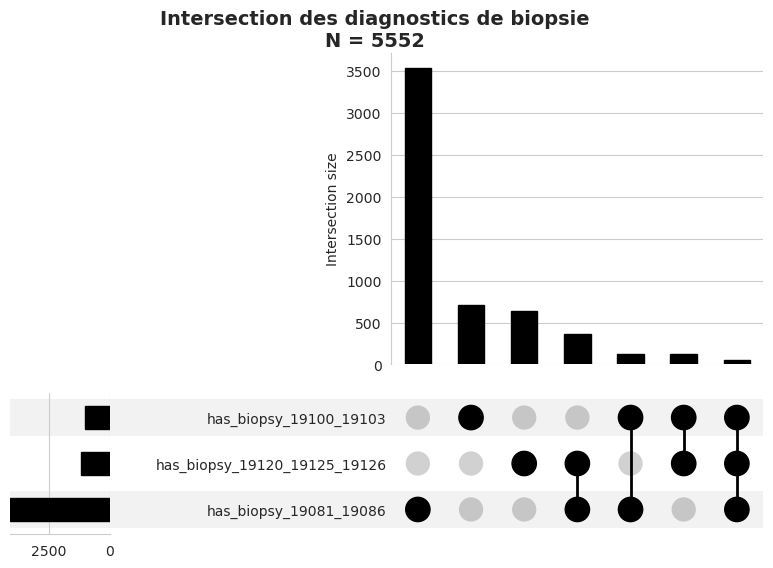

In [115]:
import matplotlib.pyplot as plt
import pandas as pd
from upsetplot import UpSet
import warnings

# Masquer les avertissements de type FutureWarning
warnings.simplefilter(action="ignore", category=FutureWarning)

# 1. Liste des colonnes cibles
cols_biopsie = [
    "has_biopsy_19081_19086",
    "has_biopsy_19100_19103",
    "has_biopsy_19120_19125_19126",
]

# 2. On crée le masque : True si au moins une colonne vaut 1
masque_au_moins_une_biopsie = (df_analysis[cols_biopsie] == 1).any(axis=1)

# 3. On applique le filtre pour créer le nouveau DataFrame nettoyé
df_with_biopsy = df_analysis[masque_au_moins_une_biopsie].copy()


# Correction de la variable N
N = len(df_with_biopsy)

# 2. Pré-agrégation propre (évite de charger les 223k lignes brutes dans UpSet)
df_bool = df_with_biopsy[cols_biopsie].astype(bool)
data_counts = df_bool.groupby(cols_biopsie).size()

# 3. Initialisation de la figure
fig = plt.figure(figsize=(14, 6))

# 4. Configuration de l'UpSetPlot
# /!\ On retire show_percentages et show_counts pour éviter le crash NumPy 2.x
up = UpSet(
    data_counts,
    sort_by="cardinality",
    element_size=50,
)

# 5. Dessin du graphique
up.plot(fig=fig)

# 6. Ajout du titre (on utilise 'y' pour éviter qu'il chevauche les barres du haut)
plt.suptitle(
    f"Intersection des diagnostics de biopsie\nN = {N}",
    fontsize=14,
    fontweight="bold",
    y=0.95,
)

# /!\ SUPPRESSION de plt.tight_layout() qui corrompait le rendu graphiques

plt.show()

## Analysis of the distribution of cancer cases by intersection

In [116]:
summary = (df_analysis
           .groupby(cols_biopsie)["has_bc"]
           .agg(
               n_individuals="count",
               n_bc="sum",
               prevalence_bc="mean")
           .reset_index()
          )

summary["prevalence_bc"] = summary["prevalence_bc"] * 100

summary["taux_bc"] = (summary["n_bc"] / df_analysis[df_analysis['has_bc'] == 1].shape[0]) * 100

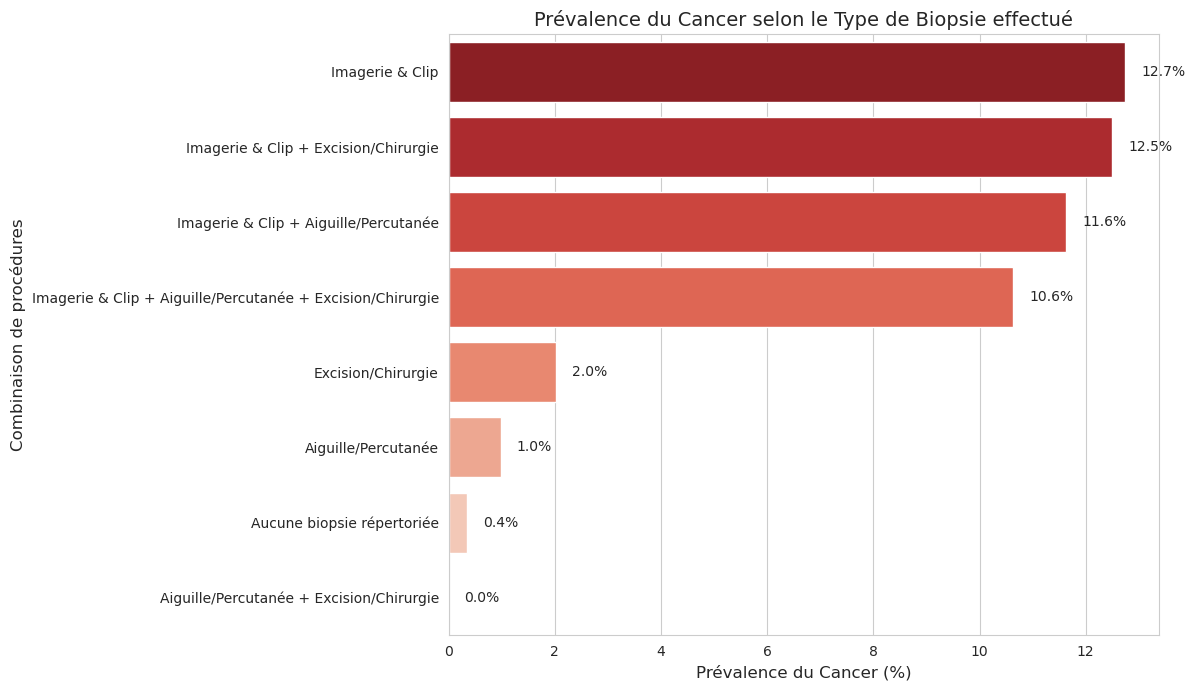

In [117]:
# 1. Création d'un dictionnaire de traduction pour les combinaisons
def label_combinaison(row):
    active = []
    if row['has_biopsy_19081_19086'] == 1: active.append("Imagerie & Clip")
    if row['has_biopsy_19100_19103'] == 1: active.append("Aiguille/Percutanée")
    if row['has_biopsy_19120_19125_19126'] == 1: active.append("Excision/Chirurgie")
    
    return " + ".join(active) if active else "Aucune biopsie répertoriée"

summary['label_fr'] = summary.apply(label_combinaison, axis=1)

# 2. Visualisation de la prévalence
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# On trie par prévalence pour une lecture plus facile
summary_sorted = summary.sort_values('prevalence_bc', ascending=False)

barplot = sns.barplot(
    data=summary_sorted, 
    x='prevalence_bc', 
    y='label_fr', 
    palette='Reds_r'
)

# Ajout des étiquettes de données sur les barres
for p in barplot.patches:
    width = p.get_width()
    plt.text(width + 0.3, p.get_y() + p.get_height()/2, 
             f'{width:.1f}%', va='center')

plt.title('Prévalence du Cancer selon le Type de Biopsie effectué', fontsize=14)
plt.xlabel('Prévalence du Cancer (%)', fontsize=12)
plt.ylabel('Combinaison de procédures', fontsize=12)
plt.tight_layout()
plt.show()

## Analysis of the number of biopsies

In [118]:
date_column = df_analysis.columns[df_analysis.columns.str.contains('date_')].drop('date_of_birth').tolist()

In [119]:
df_analysis[df_analysis['biopsy_result'] == 1][date_column+['first_any_biopsy_date']].notna().sum()

date_1_of_biopsy_19081_19086          4074
date_2_of_biopsy_19081_19086          1212
date_3_of_biopsy_19081_19086           364
date_1_of_biopsy_19100_19103          1013
date_2_of_biopsy_19100_19103           128
date_3_of_biopsy_19100_19103            18
date_1_of_biopsy_19120_19125_19126    1174
date_2_of_biopsy_19120_19125_19126      70
date_3_of_biopsy_19120_19125_19126       8
first_any_biopsy_date                 5552
dtype: int64

## Analysis of the number of days elapsed between the date of inclusion and the date of the first biopsy

In [120]:
df_analysis_v2 = df_analysis[['person_id','inclusion_date','has_bc',
                              'first_breast_cancer_date','delay_days', 'delay_years',
                              'days_biopsy_to_cancer','days_inclusion_to_biopsy',
                              'first_any_biopsy_date']+date_column].copy()

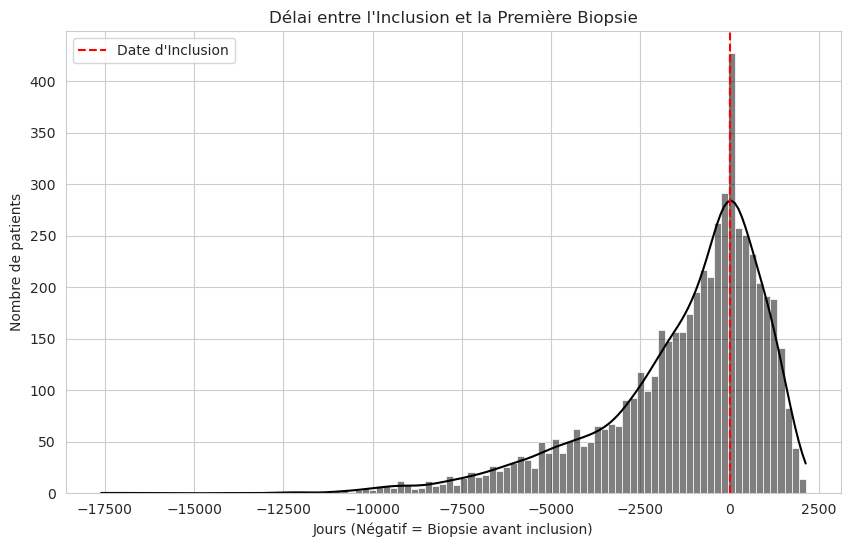

In [121]:
plt.figure(figsize=(10, 6))
sns.histplot(df_analysis_v2['days_inclusion_to_biopsy'].dropna(), bins=100, kde=True, color='black')
plt.axvline(0, color='red', linestyle='--', label='Date d\'Inclusion')
plt.title('Délai entre l\'Inclusion et la Première Biopsie')
plt.xlabel('Jours (Négatif = Biopsie avant inclusion)')
plt.ylabel('Nombre de patients')
plt.legend()
plt.show()

## Analyse du nombre de jours écoulé entre la date de déclaration du cancer et la date de la première biopsie

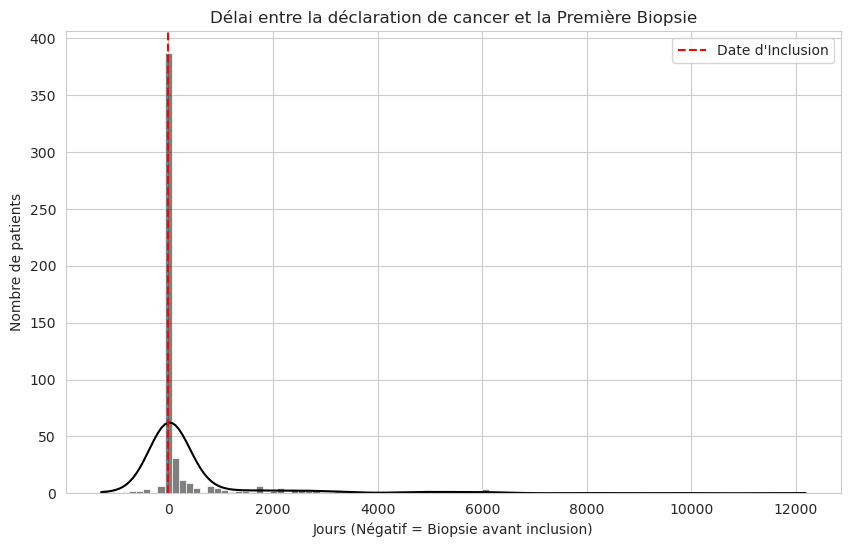

In [122]:
plt.figure(figsize=(10, 6))
sns.histplot(df_analysis_v2['days_biopsy_to_cancer'].dropna(), bins=100, kde=True, color='black')
plt.axvline(0, color='red', linestyle='--', label='Date d\'Inclusion')
plt.title('Délai entre la déclaration de cancer et la Première Biopsie')
plt.xlabel('Jours (Négatif = Biopsie avant inclusion)')
plt.ylabel('Nombre de patients')
plt.legend()
plt.show()

## Observation de la concordance temporelle : Biopsie vs Cancer

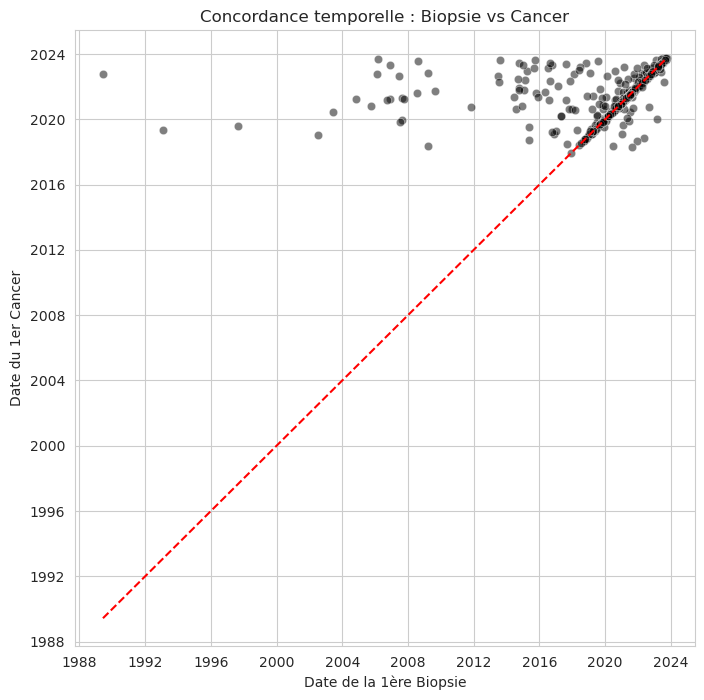

In [123]:
plt.figure(figsize=(8, 8))
# On ne garde que ceux qui ont les deux dates
temp_plot = df_analysis_v2.dropna(subset=['first_any_biopsy_date', 'first_breast_cancer_date'])

sns.scatterplot(data=temp_plot, x='first_any_biopsy_date', y='first_breast_cancer_date', alpha=0.5, color='black')

# Ligne de référence y = x
line_min = min(temp_plot['first_any_biopsy_date'].min(), temp_plot['first_breast_cancer_date'].min())
line_max = max(temp_plot['first_any_biopsy_date'].max(), temp_plot['first_breast_cancer_date'].max())
plt.plot([line_min, line_max], [line_min, line_max], color='red', linestyle='--')

plt.title('Concordance temporelle : Biopsie vs Cancer')
plt.xlabel('Date de la 1ère Biopsie')
plt.ylabel('Date du 1er Cancer')
plt.show()

## Analyse du délais entre Biopsie et Diagnostic de Cancer

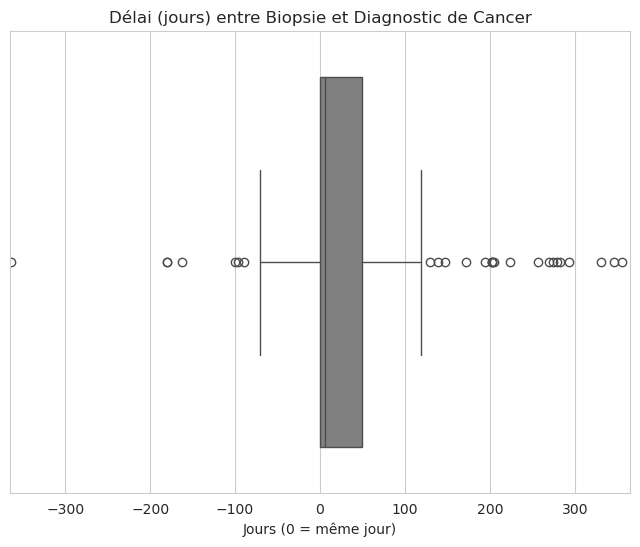

In [124]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=df_analysis['days_biopsy_to_cancer'].dropna(), color='grey')
plt.title('Délai (jours) entre Biopsie et Diagnostic de Cancer')
plt.xlabel('Jours (0 = même jour)')
# On limite l'axe pour mieux voir le pic (ex: entre -100 et 100 jours)
plt.xlim(-365, 365) 
plt.show()

# Data's export

In [125]:
destination_filename = 'Datas/df_bc_ko_at_inclusion_223k_nb_BC_WITHIN_5Y_GeneticAncestry_biopsy.tsv'
df.to_csv(destination_filename, index=False)

# Récupère le nom du bucket Google Cloud depuis la variable d’environnement
my_bucket = os.getenv('WORKSPACE_TEMP_BUCKET')

# Copie le fichier TSV local dans le dossier "Data" du bucket
args = ["gsutil", "cp", f"./{destination_filename}", f"{my_bucket}"]
output = subprocess.run(args, capture_output=True)

# Affiche les éventuelles erreurs retournées par gsutil
output.stderr

b'Copying file://./Datas/df_bc_ko_at_inclusion_223k_nb_BC_WITHIN_5Y_GeneticAncestry_biopsy.tsv [Content-Type=text/tab-separated-values]...\n/ [0 files][    0.0 B/ 44.8 MiB]                                                \r-\r- [1 files][ 44.8 MiB/ 44.8 MiB]                                                \r\nOperation completed over 1 objects/44.8 MiB.                                     \n'